# Adversarial Examples on Neural Networks

This notebook repeats the FGSM adversarial robustness experiments from the logistic regression notebook using neural networks.

The notebook has four parts:  
Part 1 - MNIST CNNs  
Part 2 - STL-10 CNNs  
Part 3 - STL-10 ResNet-18  
Part 4 - Summary

References: Szegedy et al. (2014), *Intriguing Properties of Neural
Networks*; Goodfellow et al. (2015), *Explaining and Harnessing Adversarial
Examples*.

## 0. Setup

In [2]:
import json
import os

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from data import (
    device,
    train_loader_bin_img,
    test_loader_bin_img,
    train_loader,
    test_loader,
    load_stl10
)

from models import (
    BinaryCNNMNIST,
    MulticlassCNNMNIST,
    BinaryCNNSTL10,
    MulticlassCNNSTL10,
    BinaryResNetSTL10,
    MulticlassResNetSTL10
)

from train import (
    train_binary_cnn,
    train_multiclass_cnn,
    train_binary_cnn_adversarial,
    train_multiclass_cnn_adversarial,
    train_binary_resnet,
    train_multiclass_resnet,
    train_binary_resnet_adversarial,
    train_multiclass_resnet_adversarial,
    eval_binary,
    eval_multiclass,
    evaluate_fgsm_binary,
    evaluate_fgsm_multiclass,
    evaluate_noise_binary,
    evaluate_noise_multiclass,
    bce
)

from attacks import (
    fgsm_attack,
    gaussian_noise_attack,
    random_sign_attack
)

print("Using device:", device)

with open("logreg_results.json") as f:
    logreg_results = json.load(f)

Using device: cuda


We add a function that plots logistic regression results with this notebook's results

In [3]:
# AI assistance was used for matching colors across CNN and logistic regression curves

def overlay_plot(title, epsilons, cnn_results, logreg_key):
    plt.figure(figsize=(7.5, 4.8))

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    used_colors = {}

    # CNN results
    for i, (name, accs) in enumerate(cnn_results.items()):
        color = colors[i % len(colors)]
        used_colors[name] = color

        plt.plot(epsilons, accs, marker="o", color=color, label="CNN: " + name)

    # matching logistic regression results
    lr_data = logreg_results[logreg_key]
    lr_eps = lr_data["epsilons"]

    for name in cnn_results:
        if name == "binary" or name == "multiclass":
            lr_name = "no regularization"
        else:
            lr_name = name

        if lr_name in lr_data:
            plt.plot(
                lr_eps,
                lr_data[lr_name],
                marker="x",
                linestyle="--",
                color=used_colors[name],
                alpha=0.6,
                label="log reg: " + lr_name
            )

    plt.xlabel("epsilon")
    plt.ylabel("test accuracy")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    plt.show()

# Part 1 - MNIST CNNs

## 1.1 Binary model training

In [4]:
print("Training CNN:")

cnn_bin_MNIST = train_binary_cnn(train_loader_bin_img, dataset="mnist", epochs=15, lr=0.01)

test_acc = eval_binary(cnn_bin_MNIST, test_loader_bin_img)
print("Test accuracy:", round(test_acc, 4))

Training CNN:
epoch 1 | loss: 0.4318 | train acc: 0.851
epoch 5 | loss: 0.0234 | train acc: 0.9927
epoch 10 | loss: 0.0103 | train acc: 0.997
epoch 15 | loss: 0.0053 | train acc: 0.9989
Test accuracy: 0.9975


## 1.2 FGSM on the binary CNN

In [5]:
EPSILONS_MNIST = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25]

bin_mnist_accs = []

for epsilon in EPSILONS_MNIST:
    if epsilon == 0.0:
        acc = test_acc
    else:
        acc = evaluate_fgsm_binary(cnn_bin_MNIST, test_loader_bin_img, epsilon)

    bin_mnist_accs.append(acc)

cnn_results_bin = {"binary": bin_mnist_accs}

print("Binary accuracies:")
print([round(acc, 3) for acc in bin_mnist_accs])

Binary accuracies:
[0.997, 0.994, 0.982, 0.906, 0.671, 0.386, 0.139]


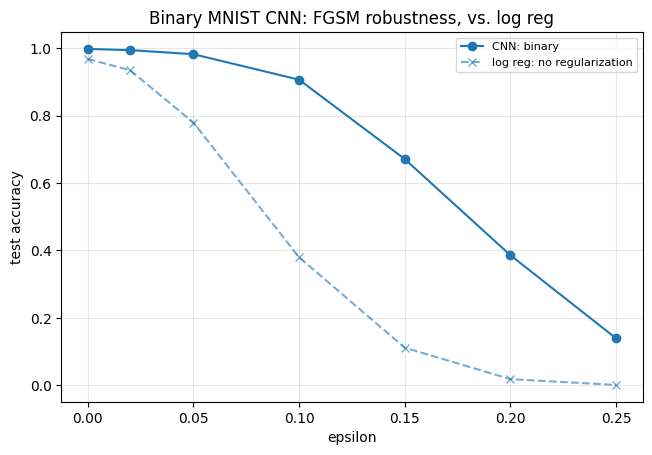

In [6]:
overlay_plot(
    "Binary MNIST CNN: FGSM robustness, vs. log reg", EPSILONS_MNIST, cnn_results_bin, "mnist_binary")

## 1.3 Visualizing adversarial examples

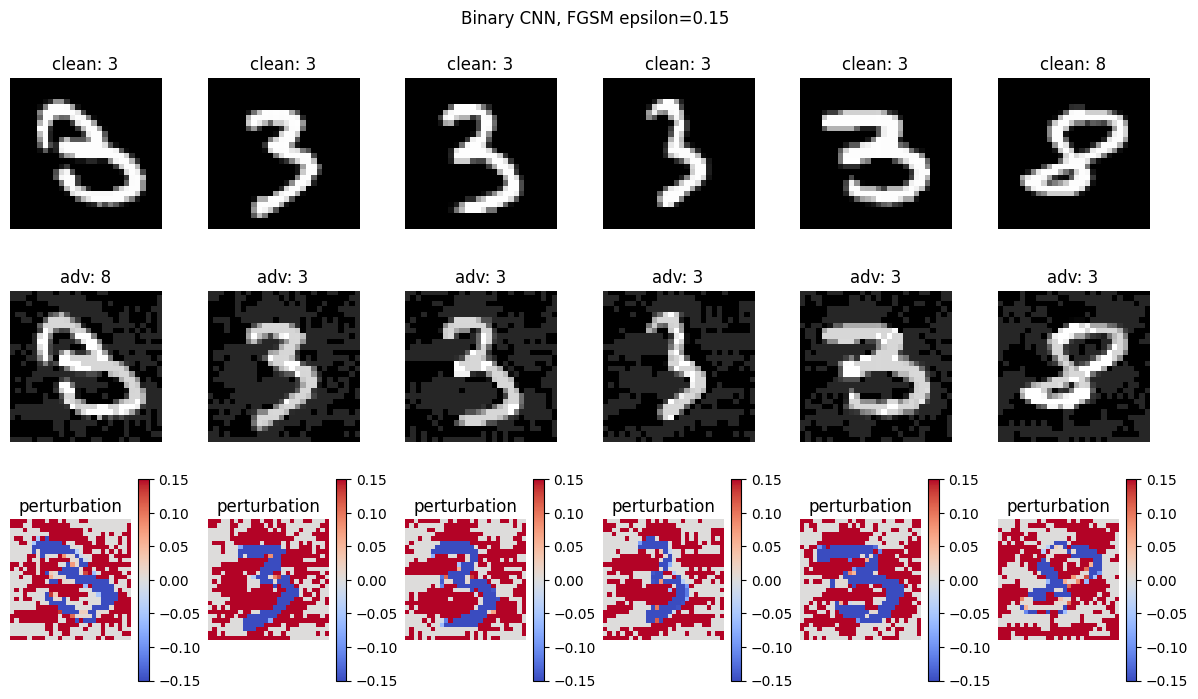

In [7]:
def show_binary_adversarials(model, loader, epsilon, n=6):
    """
    Show clean images, FGSM adversarial examples, and perturbations
    """
    model.eval()

    x_list = []
    y_list = []
    num_images = 0

    # collect correctly classified clean images
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        with torch.no_grad():
            preds = (model(x_batch) > 0.5).long()

        mask = preds == y_batch

        x_correct = x_batch[mask]
        y_correct = y_batch[mask]

        x_list.append(x_correct)
        y_list.append(y_correct)

        num_images += x_correct.size(0)

        if num_images >= n:
            break

    x = torch.cat(x_list)[:n]
    y = torch.cat(y_list)[:n]

    x_adv = fgsm_attack(model, x, y, epsilon, bce)

    with torch.no_grad():
        clean_preds = (model(x) > 0.5).long().cpu()
        adv_preds = (model(x_adv) > 0.5).long().cpu()

    label_names = {0: "3", 1: "8"}

    x = x.cpu()
    x_adv = x_adv.cpu()
    perturbation = x_adv - x

    fig, axes = plt.subplots(3, n, figsize=(2 * n, 7))

    for i in range(n):
        axes[0, i].imshow(x[i, 0], cmap="gray")
        axes[0, i].set_title("clean: " + label_names[clean_preds[i].item()])
        axes[0, i].axis("off")

        axes[1, i].imshow(x_adv[i, 0], cmap="gray")
        axes[1, i].set_title("adv: " + label_names[adv_preds[i].item()])
        axes[1, i].axis("off")

        im = axes[2, i].imshow(perturbation[i, 0], cmap="coolwarm")
        fig.colorbar(im, ax=axes[2, i])
        axes[2, i].set_title("perturbation")
        axes[2, i].axis("off")

    plt.suptitle("Binary CNN, FGSM epsilon=" + str(epsilon))
    plt.tight_layout()
    plt.show()


show_binary_adversarials(cnn_bin_MNIST, test_loader_bin_img, epsilon=0.15)

## 1.4 Adversarial training

In [8]:
print("Training FGSM adversarial CNN:")

cnn_bin_MNIST_adv = train_binary_cnn_adversarial(train_loader_bin_img, dataset="mnist", epsilon=0.15, epochs=15)

clean_acc_adv = eval_binary(cnn_bin_MNIST_adv,test_loader_bin_img)

print("Clean test accuracy (adversarial training):", round(clean_acc_adv, 4))

Training FGSM adversarial CNN:
epoch 1 | loss: 0.5338 | train acc (clean): 0.8746
epoch 5 | loss: 0.0961 | train acc (clean): 0.9941
epoch 10 | loss: 0.0618 | train acc (clean): 0.9972
epoch 15 | loss: 0.0394 | train acc (clean): 0.9987
Clean test accuracy (adversarial training): 0.9985


In [9]:
mnist_bin_adv_accs = []

for epsilon in EPSILONS_MNIST:
    if epsilon == 0.0:
        acc = clean_acc_adv
    else:
        acc = evaluate_fgsm_binary(cnn_bin_MNIST_adv, test_loader_bin_img, epsilon)

    mnist_bin_adv_accs.append(acc)

cnn_results_bin["adversarial training"] = mnist_bin_adv_accs

print("Adversarial training accuracies:")
print([round(acc, 3) for acc in mnist_bin_adv_accs])

Adversarial training accuracies:
[0.998, 0.998, 0.998, 0.992, 0.98, 0.945, 0.872]


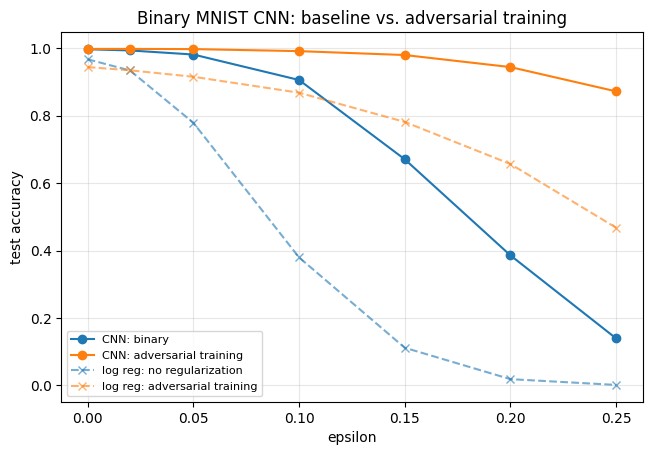

In [10]:
overlay_plot("Binary MNIST CNN: baseline vs. adversarial training", EPSILONS_MNIST, cnn_results_bin, "mnist_binary")

## 1.5 Comparison with random noise

In [11]:
for noise_name, noise_fn in [("gaussian noise", gaussian_noise_attack), ("random sign noise", random_sign_attack)]:
    noise_accs = []

    for epsilon in EPSILONS_MNIST:
        if epsilon == 0.0:
            acc = test_acc
        else:
            acc = evaluate_noise_binary(cnn_bin_MNIST, test_loader_bin_img, epsilon, noise_fn)

        noise_accs.append(acc)

    cnn_results_bin[noise_name] = noise_accs

    print(noise_name + " accuracies:")
    print([round(acc, 3) for acc in noise_accs])

gaussian noise accuracies:
[0.997, 0.997, 0.997, 0.997, 0.998, 0.997, 0.998]
random sign noise accuracies:
[0.997, 0.997, 0.997, 0.998, 0.997, 0.998, 0.996]


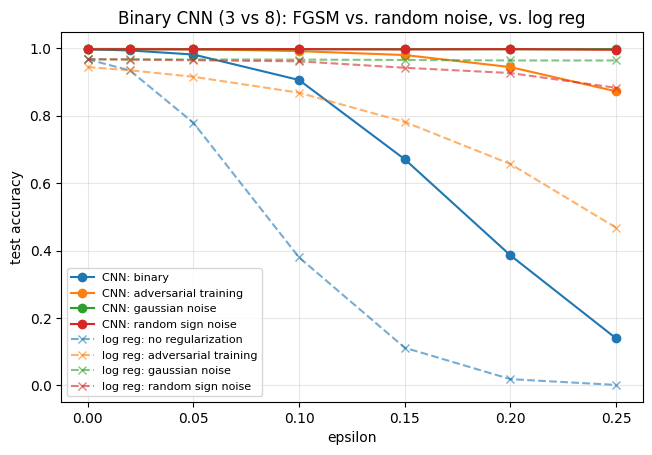

In [12]:
overlay_plot("Binary CNN (3 vs 8): FGSM vs. random noise, vs. log reg", EPSILONS_MNIST, cnn_results_bin, "mnist_binary")

## 1.6 Multiclass model training

In [13]:
print("Training multiclass CNN:")

cnn_mc_MNIST = train_multiclass_cnn(train_loader, dataset="mnist", epochs=15, lr=0.01)

test_acc = eval_multiclass(cnn_mc_MNIST, test_loader)

print("Test accuracy:", round(test_acc, 4))

Training multiclass CNN:
epoch 1 | loss: 0.4229 | train acc: 0.8708
epoch 5 | loss: 0.0376 | train acc: 0.9885
epoch 10 | loss: 0.0175 | train acc: 0.9946
epoch 15 | loss: 0.0096 | train acc: 0.9972
Test accuracy: 0.9909


## 1.7 FGSM on the multiclass CNN

In [14]:
mc_mnist_accs = []

for epsilon in EPSILONS_MNIST:
    if epsilon == 0.0:
        acc = test_acc
    else:
        acc = evaluate_fgsm_multiclass(cnn_mc_MNIST, test_loader, epsilon)

    mc_mnist_accs.append(acc)

cnn_results_mc = {"multiclass": mc_mnist_accs}

print("Multiclass accuracies:")
print([round(acc, 3) for acc in mc_mnist_accs])

Multiclass accuracies:
[0.991, 0.982, 0.952, 0.809, 0.549, 0.324, 0.215]


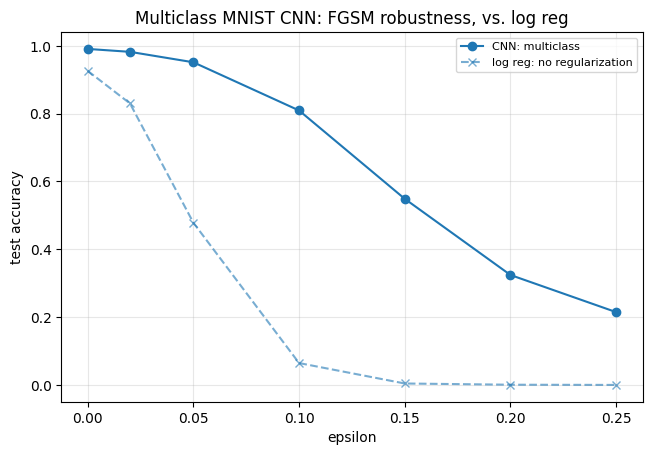

In [15]:
overlay_plot("Multiclass MNIST CNN: FGSM robustness, vs. log reg", EPSILONS_MNIST, cnn_results_mc, "mnist_multiclass")

## 1.8 Visualizing adversarial examples

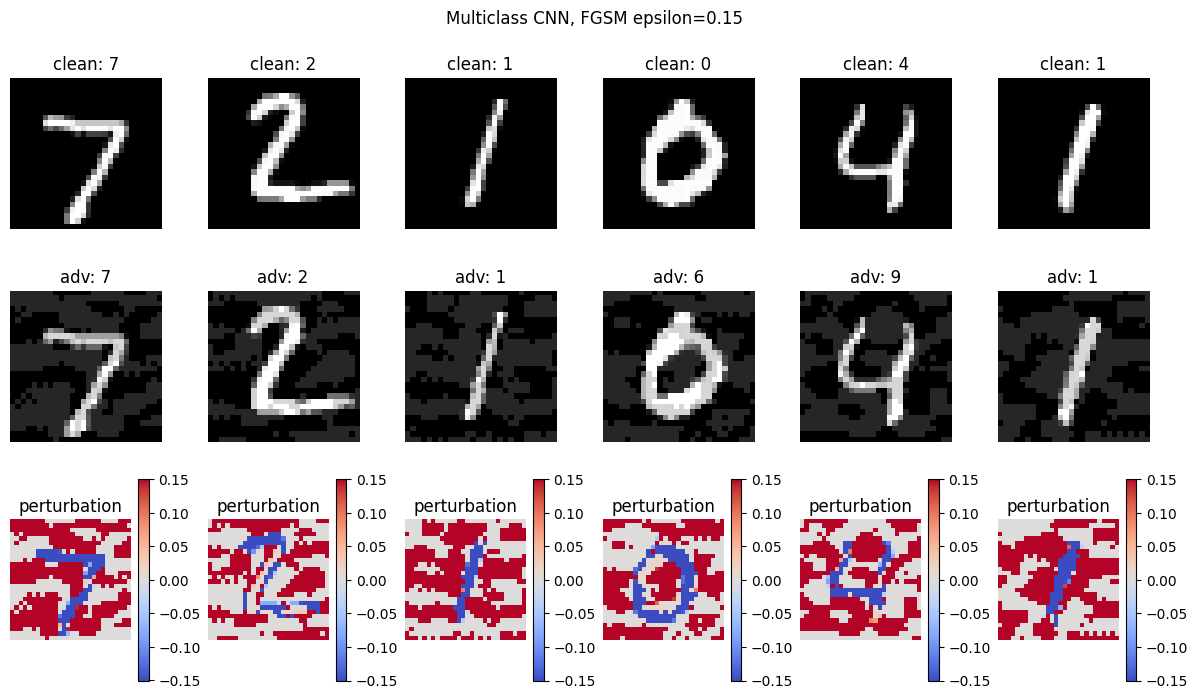

In [16]:
def show_multiclass_adversarials(model, loader, epsilon, n=6):
    """
    Show clean images, FGSM adversarial examples, and perturbations
    """
    model.eval()

    x_list = []
    y_list = []
    num_images = 0

    # collect correctly classified clean images
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        with torch.no_grad():
            preds = model(x_batch).argmax(1)

        mask = preds == y_batch

        x_correct = x_batch[mask]
        y_correct = y_batch[mask]

        x_list.append(x_correct)
        y_list.append(y_correct)

        num_images += x_correct.size(0)

        if num_images >= n:
            break

    x = torch.cat(x_list)[:n]
    y = torch.cat(y_list)[:n]

    x_adv = fgsm_attack(model, x, y, epsilon, F.cross_entropy)

    with torch.no_grad():
        clean_preds = model(x).argmax(1).cpu()
        adv_preds = model(x_adv).argmax(1).cpu()

    x = x.cpu()
    x_adv = x_adv.cpu()
    perturbation = x_adv - x

    fig, axes = plt.subplots(3, n, figsize=(2 * n, 7))

    for i in range(n):
        axes[0, i].imshow(x[i, 0], cmap="gray")
        axes[0, i].set_title("clean: " + str(clean_preds[i].item()))
        axes[0, i].axis("off")

        axes[1, i].imshow(x_adv[i, 0], cmap="gray")
        axes[1, i].set_title("adv: " + str(adv_preds[i].item()))
        axes[1, i].axis("off")

        im = axes[2, i].imshow(perturbation[i, 0], cmap="coolwarm")
        fig.colorbar(im, ax=axes[2, i])
        axes[2, i].set_title("perturbation")
        axes[2, i].axis("off")

    plt.suptitle("Multiclass CNN, FGSM epsilon=" + str(epsilon))
    plt.tight_layout()
    plt.show()


show_multiclass_adversarials(cnn_mc_MNIST, test_loader, epsilon=0.15)

## 1.9 Adversarial training

In [17]:
print("Training FGSM adversarial CNN:")

cnn_mc_adv = train_multiclass_cnn_adversarial(train_loader, dataset="mnist", epsilon=0.15, adv_weight=0.5, epochs=15, lr=0.01)

clean_acc_adv = eval_multiclass(cnn_mc_adv, test_loader)

print("Clean test accuracy (adversarial training):", round(clean_acc_adv, 4))

Training FGSM adversarial CNN:
epoch 1 | loss: 0.7702 | train acc (clean): 0.8501
epoch 5 | loss: 0.1348 | train acc (clean): 0.9894
epoch 10 | loss: 0.0901 | train acc (clean): 0.9941
epoch 15 | loss: 0.0697 | train acc (clean): 0.9962
Clean test accuracy (adversarial training): 0.9924


In [18]:
mc_mnist_adv_accs = []

for epsilon in EPSILONS_MNIST:
    if epsilon == 0.0:
        acc = clean_acc_adv
    else:
        acc = evaluate_fgsm_multiclass(cnn_mc_adv, test_loader, epsilon)

    mc_mnist_adv_accs.append(acc)

cnn_results_mc["adversarial training"] = mc_mnist_adv_accs

print("Adversarial training accuracies:")
print([round(acc, 3) for acc in mc_mnist_adv_accs])

print("Multiclass accuracies:")
print([round(acc, 3) for acc in mc_mnist_accs])


Adversarial training accuracies:
[0.992, 0.99, 0.985, 0.97, 0.942, 0.891, 0.797]
Multiclass accuracies:
[0.991, 0.982, 0.952, 0.809, 0.549, 0.324, 0.215]


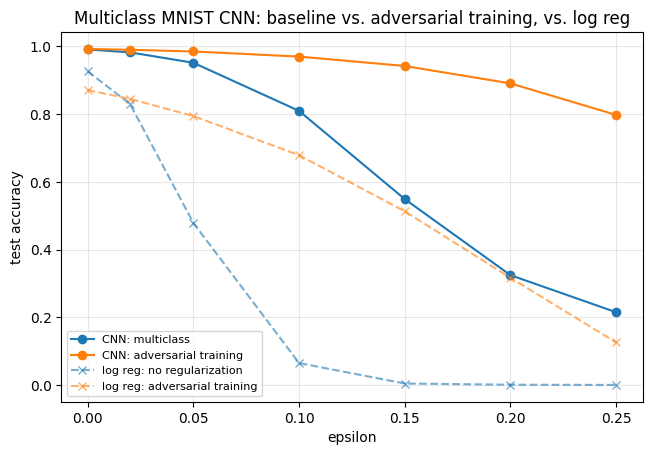

In [19]:
overlay_plot("Multiclass MNIST CNN: baseline vs. adversarial training, vs. log reg", EPSILONS_MNIST, cnn_results_mc, "mnist_multiclass")

## 1.10 Comparison with random noise

In [20]:
for noise_name, noise_fn in [
    ("gaussian noise", gaussian_noise_attack),
    ("random sign noise", random_sign_attack)
]:
    noise_accs = []

    for epsilon in EPSILONS_MNIST:
        if epsilon == 0.0:
            acc = test_acc
        else:
            acc = evaluate_noise_multiclass(cnn_mc_MNIST, test_loader, epsilon, noise_fn)

        noise_accs.append(acc)

    cnn_results_mc[noise_name] = noise_accs

    print(noise_name + " accuracies:")
    print([round(acc, 3) for acc in noise_accs])


gaussian noise accuracies:
[0.991, 0.991, 0.991, 0.991, 0.991, 0.99, 0.99]
random sign noise accuracies:
[0.991, 0.991, 0.991, 0.99, 0.99, 0.986, 0.983]


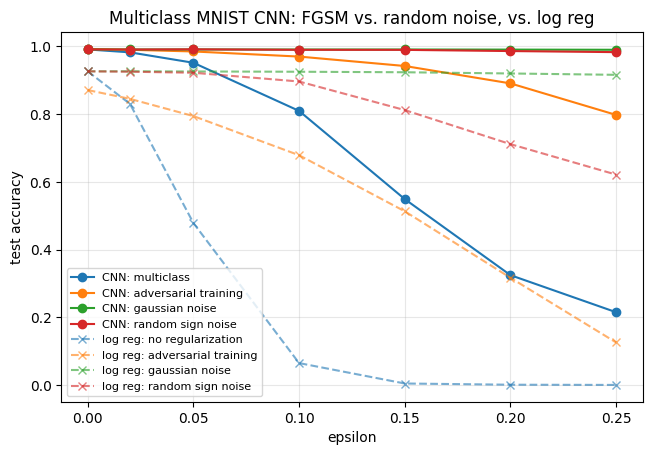

In [21]:
overlay_plot("Multiclass MNIST CNN: FGSM vs. random noise, vs. log reg", EPSILONS_MNIST, cnn_results_mc, "mnist_multiclass")

# Part 2 - STL-10 CNNs

In [22]:
from data import load_stl10

stl = load_stl10()

STL_DIM = stl["STL_DIM"]

stl_train = stl["stl_train"]
stl_test = stl["stl_test"]

stl_train_bin_img = stl["stl_train_bin_img"]
stl_test_bin_img = stl["stl_test_bin_img"]

stl_train_loader_bin_img = stl["stl_train_loader_bin_img"]
stl_test_loader_bin_img = stl["stl_test_loader_bin_img"]

stl_train_loader = stl["stl_train_loader"]
stl_test_loader = stl["stl_test_loader"]

stl_name_a = stl["stl_name_a"]
stl_name_b = stl["stl_name_b"]

100%|██████████| 2.64G/2.64G [02:32<00:00, 17.3MB/s]


## 2.1 Binary model training

In [23]:
print("Training CNN:")

stl_cnn_bin = train_binary_cnn(stl_train_loader_bin_img, dataset="stl10", epochs=30, lr=0.01)

test_acc = eval_binary(stl_cnn_bin, stl_test_loader_bin_img)

print("Test accuracy:", round(test_acc, 4))

Training CNN:
epoch 1 | loss: 0.6933 | train acc: 0.5
epoch 5 | loss: 0.6917 | train acc: 0.506
epoch 10 | loss: 0.6863 | train acc: 0.561
epoch 15 | loss: 0.6697 | train acc: 0.595
epoch 20 | loss: 0.6516 | train acc: 0.627
epoch 25 | loss: 0.6092 | train acc: 0.682
epoch 30 | loss: 0.6015 | train acc: 0.673
Test accuracy: 0.6613


## 2.2 FGSM on the binary model

In [24]:
EPSILONS_STL = [0.0, 0.002, 0.005, 0.01, 0.015, 0.02, 0.025]

stl_bin_accs = []

for epsilon in EPSILONS_STL:
    if epsilon == 0.0:
        acc = test_acc
    else:
        acc = evaluate_fgsm_binary(stl_cnn_bin, stl_test_loader_bin_img, epsilon)

    stl_bin_accs.append(acc)

stl_cnn_results_bin = {"binary": stl_bin_accs}

print("Binary accuracies:")
print([round(acc, 3) for acc in stl_bin_accs])

Binary accuracies:
[0.661, 0.622, 0.573, 0.487, 0.401, 0.319, 0.236]


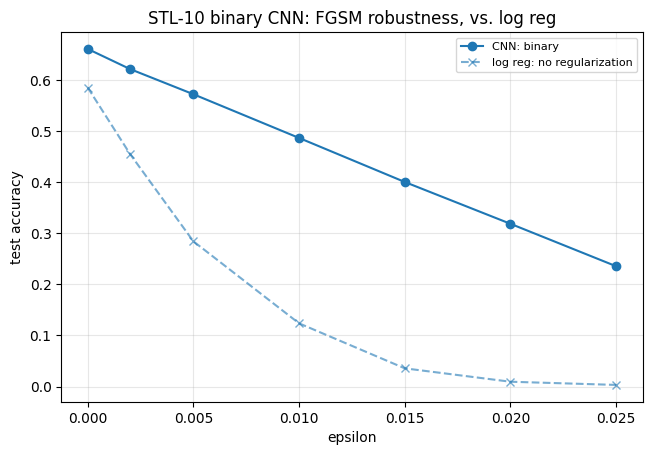

In [25]:
overlay_plot("STL-10 binary CNN: FGSM robustness, vs. log reg", EPSILONS_STL, stl_cnn_results_bin, "stl_binary")

## 2.3 Visualizing adversarial examples

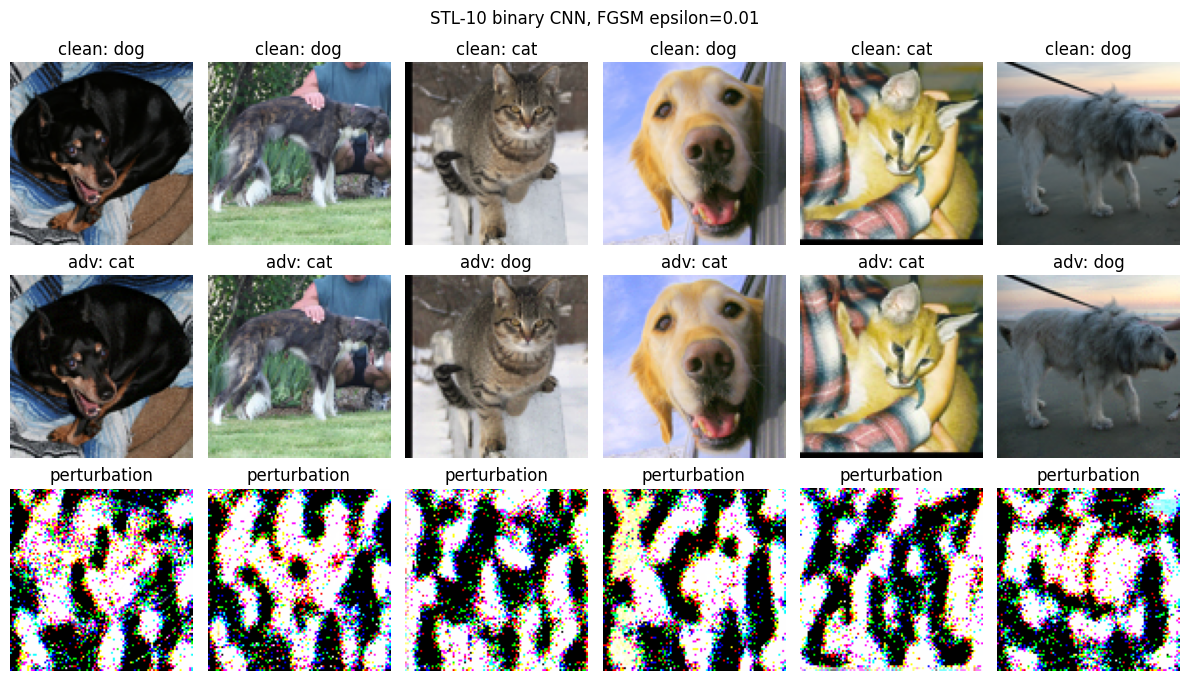

In [26]:
def show_stl_binary_adversarials(model, loader, epsilon, n=6):
    model.eval()

    x_list = []
    y_list = []
    num_images = 0

    # collect correctly classified clean images
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        with torch.no_grad():
            preds = (model(x_batch) > 0.5).long()

        mask = preds == y_batch

        x_correct = x_batch[mask]
        y_correct = y_batch[mask]

        x_list.append(x_correct)
        y_list.append(y_correct)

        num_images += x_correct.size(0)

        if num_images >= n:
            break

    x = torch.cat(x_list)[:n]
    y = torch.cat(y_list)[:n]

    x_adv = fgsm_attack(model, x, y, epsilon, bce)

    with torch.no_grad():
        clean_preds = (model(x) > 0.5).long().cpu()
        adv_preds = (model(x_adv) > 0.5).long().cpu()

    label_names = {0: stl_name_a, 1: stl_name_b}

    x = x.cpu()
    x_adv = x_adv.cpu()
    perturbation = x_adv - x

    fig, axes = plt.subplots(3, n, figsize=(2 * n, 7))

    for i in range(n):
        axes[0, i].imshow(x[i].permute(1, 2, 0))
        axes[0, i].set_title("clean: " + label_names[clean_preds[i].item()])
        axes[0, i].axis("off")

        axes[1, i].imshow(x_adv[i].permute(1, 2, 0))
        axes[1, i].set_title("adv: " + label_names[adv_preds[i].item()])
        axes[1, i].axis("off")

        # rescale perturbation values so they can be shown as an RGB image
        pert_img = (perturbation[i] / epsilon + 1) / 2
        pert_img = pert_img.permute(1, 2, 0).clamp(0, 1)

        axes[2, i].imshow(pert_img)
        axes[2, i].set_title("perturbation")
        axes[2, i].axis("off")

    plt.suptitle("STL-10 binary CNN, FGSM epsilon=" + str(epsilon))
    plt.tight_layout()
    plt.show()


show_stl_binary_adversarials(stl_cnn_bin, stl_test_loader_bin_img, epsilon=0.01)

## 2.4 Adversarial training

In [27]:
print("Training FGSM adversarial CNN:")

stl_cnn_bin_adv = train_binary_cnn_adversarial(stl_train_loader_bin_img, dataset="stl10", epsilon=0.015, epochs=30)

clean_acc_adv = eval_binary(stl_cnn_bin_adv, stl_test_loader_bin_img)

print("Clean test accuracy (adversarial training):", round(clean_acc_adv, 4))

Training FGSM adversarial CNN:
epoch 1 | loss: 0.6977 | train acc (clean): 0.5
epoch 5 | loss: 0.6952 | train acc (clean): 0.5
epoch 10 | loss: 0.6944 | train acc (clean): 0.5
epoch 15 | loss: 0.694 | train acc (clean): 0.507
epoch 20 | loss: 0.6937 | train acc (clean): 0.566
epoch 25 | loss: 0.6935 | train acc (clean): 0.559
epoch 30 | loss: 0.6934 | train acc (clean): 0.564
Clean test accuracy (adversarial training): 0.5519


In [28]:
stl_bin_adv_accs = []

for epsilon in EPSILONS_STL:
    if epsilon == 0.0:
        acc = clean_acc_adv
    else:
        acc = evaluate_fgsm_binary(stl_cnn_bin_adv, stl_test_loader_bin_img, epsilon)

    stl_bin_adv_accs.append(acc)

stl_cnn_results_bin["adversarial training"] = stl_bin_adv_accs

print("Adversarial training accuracies:")
print([round(acc, 3) for acc in stl_bin_adv_accs])



Adversarial training accuracies:
[0.552, 0.494, 0.427, 0.352, 0.304, 0.273, 0.248]


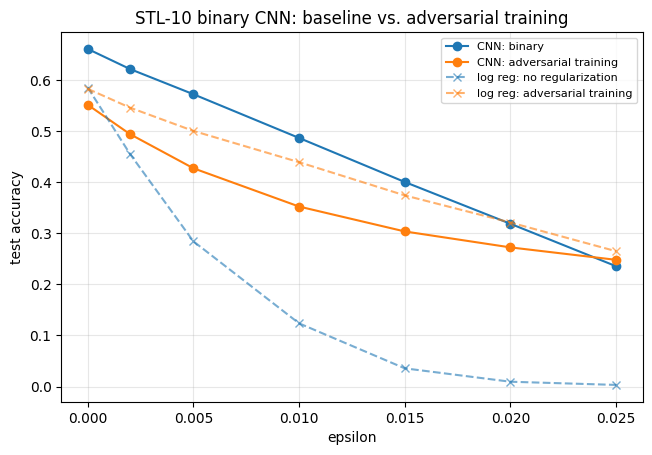

In [29]:
overlay_plot("STL-10 binary CNN: baseline vs. adversarial training", EPSILONS_STL, stl_cnn_results_bin, "stl_binary")

## 2.5 Comparison with random noise

In [30]:
for noise_name, noise_fn in [("gaussian noise", gaussian_noise_attack), ("random sign noise", random_sign_attack)]:
    noise_accs = []

    for epsilon in EPSILONS_STL:
        if epsilon == 0.0:
            acc = test_acc
        else:
            acc = evaluate_noise_binary(stl_cnn_bin, stl_test_loader_bin_img, epsilon, noise_fn)

        noise_accs.append(acc)

    stl_cnn_results_bin[noise_name] = noise_accs

    print(noise_name + " accuracies:")
    print([round(acc, 3) for acc in noise_accs])


gaussian noise accuracies:
[0.661, 0.661, 0.661, 0.661, 0.661, 0.661, 0.661]
random sign noise accuracies:
[0.661, 0.661, 0.661, 0.66, 0.66, 0.659, 0.659]


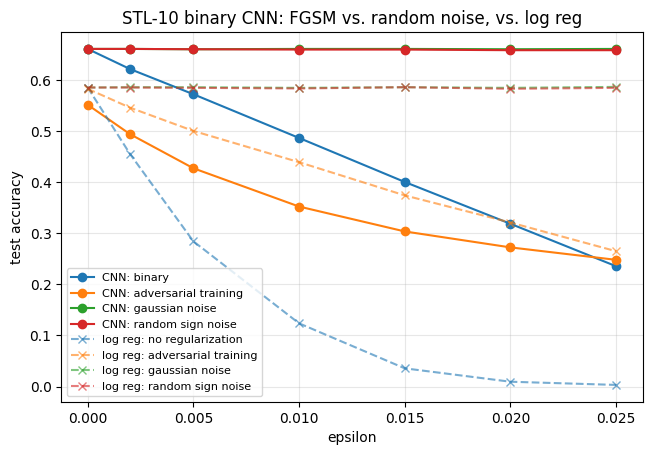

In [31]:
overlay_plot("STL-10 binary CNN: FGSM vs. random noise, vs. log reg", EPSILONS_STL, stl_cnn_results_bin, "stl_binary")

## 2.6 Multiclass model training

In [32]:
print("Training multiclass CNN:")

stl_cnn_mc = train_multiclass_cnn(stl_train_loader, dataset="stl10", epochs=30, lr=0.01)

test_acc = eval_multiclass(stl_cnn_mc, stl_test_loader)

print("Test accuracy:", round(test_acc, 4))

Training multiclass CNN:
epoch 1 | loss: 2.292 | train acc: 0.1214
epoch 5 | loss: 1.6874 | train acc: 0.3714
epoch 10 | loss: 1.2807 | train acc: 0.5272
epoch 15 | loss: 0.9529 | train acc: 0.6528
epoch 20 | loss: 0.4502 | train acc: 0.8414
epoch 25 | loss: 0.1358 | train acc: 0.9574
epoch 30 | loss: 0.0082 | train acc: 0.9984
Test accuracy: 0.5395


## 2.7 FGSM on the multiclass model

In [33]:
stl_mult_accs = []

for epsilon in EPSILONS_STL:
    if epsilon == 0.0:
        acc = test_acc
    else:
        acc = evaluate_fgsm_multiclass(stl_cnn_mc, stl_test_loader, epsilon)

    stl_mult_accs.append(acc)

stl_cnn_results_mc = {"multiclass": stl_mult_accs}

print("Multiclass accuracies:")
print([round(acc, 3) for acc in stl_mult_accs])

Multiclass accuracies:
[0.539, 0.463, 0.356, 0.233, 0.152, 0.112, 0.094]


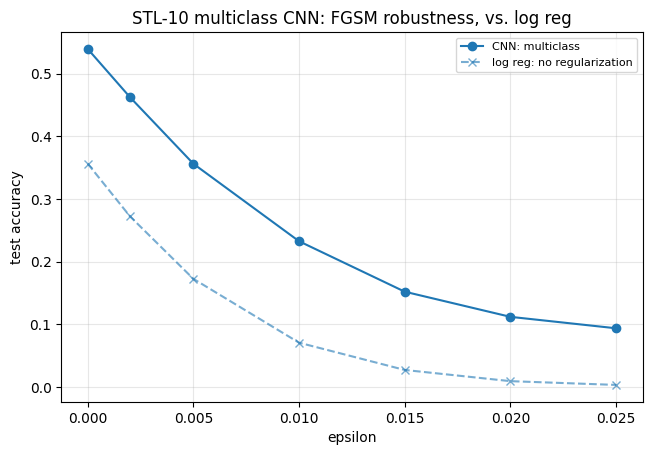

In [34]:
overlay_plot("STL-10 multiclass CNN: FGSM robustness, vs. log reg", EPSILONS_STL, stl_cnn_results_mc, "stl_multiclass")

## 2.8 Visualizing adversarial examples

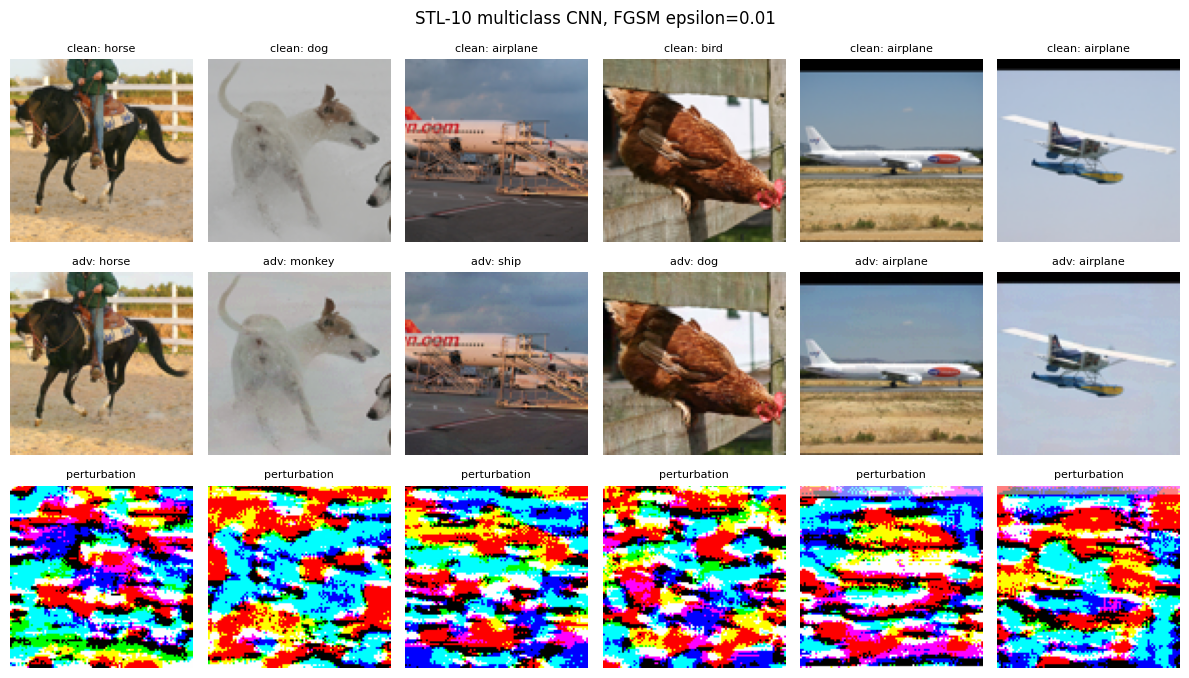

In [35]:
def show_stl_multiclass_adversarials(model, loader, epsilon, n=6):

    model.eval()

    x_list = []
    y_list = []
    num_images = 0

    # collect correctly classified clean images
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        with torch.no_grad():
            preds = model(x_batch).argmax(1)

        mask = preds == y_batch

        x_correct = x_batch[mask]
        y_correct = y_batch[mask]

        x_list.append(x_correct)
        y_list.append(y_correct)

        num_images += x_correct.size(0)

        if num_images >= n:
            break

    x = torch.cat(x_list)[:n]
    y = torch.cat(y_list)[:n]

    x_adv = fgsm_attack(model, x, y, epsilon, F.cross_entropy)

    with torch.no_grad():
        clean_preds = model(x).argmax(1).cpu()
        adv_preds = model(x_adv).argmax(1).cpu()

    class_names = stl_train.classes

    x = x.cpu()
    x_adv = x_adv.cpu()
    perturbation = x_adv - x

    fig, axes = plt.subplots(3, n, figsize=(2 * n, 7))

    for i in range(n):
        axes[0, i].imshow(x[i].permute(1, 2, 0))
        axes[0, i].set_title(
            "clean: " + class_names[clean_preds[i].item()],
            fontsize=8
        )
        axes[0, i].axis("off")

        axes[1, i].imshow(x_adv[i].permute(1, 2, 0))
        axes[1, i].set_title(
            "adv: " + class_names[adv_preds[i].item()],
            fontsize=8
        )
        axes[1, i].axis("off")

        # rescale perturbation values so they can be shown as an RGB image
        pert_img = (perturbation[i] / epsilon + 1) / 2
        pert_img = pert_img.permute(1, 2, 0).clamp(0, 1)

        axes[2, i].imshow(pert_img)
        axes[2, i].set_title("perturbation", fontsize=8)
        axes[2, i].axis("off")

    plt.suptitle("STL-10 multiclass CNN, FGSM epsilon=" + str(epsilon))
    plt.tight_layout()
    plt.show()


show_stl_multiclass_adversarials(stl_cnn_mc, stl_test_loader, epsilon=0.01)

## 2.9 Adversarial training

In [36]:
print("Training FGSM adversarial CNN (STL-10):")

stl_cnn_mc_adv = train_multiclass_cnn_adversarial(stl_train_loader, dataset="stl10", epsilon=0.015, adv_weight=0.5, epochs=30, lr=0.01)

clean_acc_adv = eval_multiclass(stl_cnn_mc_adv, stl_test_loader)

print("Clean test accuracy (adversarial training):", round(clean_acc_adv, 4))

Training FGSM adversarial CNN (STL-10):
epoch 1 | loss: 2.3025 | train acc (clean): 0.153
epoch 5 | loss: 1.8699 | train acc (clean): 0.3214
epoch 10 | loss: 1.5543 | train acc (clean): 0.4638
epoch 15 | loss: 1.2477 | train acc (clean): 0.6166
epoch 20 | loss: 0.8219 | train acc (clean): 0.8204
epoch 25 | loss: 0.3465 | train acc (clean): 0.9636
epoch 30 | loss: 0.0256 | train acc (clean): 0.9996
Clean test accuracy (adversarial training): 0.5514


In [37]:
stl_mc_adv_accs = []

for epsilon in EPSILONS_STL:
    if epsilon == 0.0:
        acc = clean_acc_adv
    else:
        acc = evaluate_fgsm_multiclass(stl_cnn_mc_adv, stl_test_loader, epsilon)

    stl_mc_adv_accs.append(acc)

stl_cnn_results_mc["adversarial training"] = stl_mc_adv_accs

print("Adversarial training accuracies:")
print([round(acc, 3) for acc in stl_mc_adv_accs])

Adversarial training accuracies:
[0.551, 0.512, 0.449, 0.358, 0.281, 0.225, 0.177]


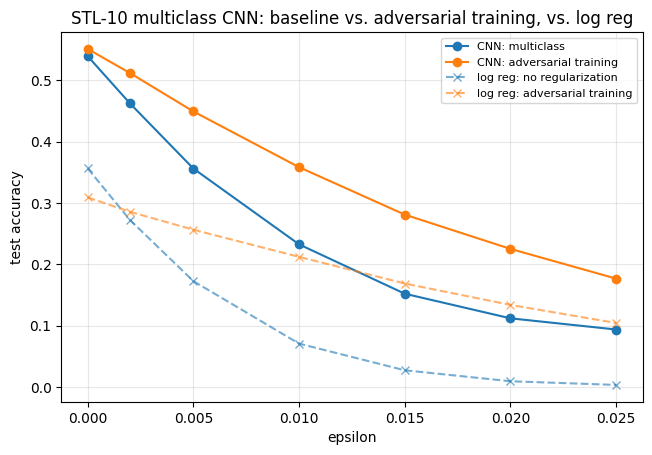

In [38]:
overlay_plot("STL-10 multiclass CNN: baseline vs. adversarial training, vs. log reg", EPSILONS_STL, stl_cnn_results_mc, "stl_multiclass")

## 2.10 Comparison with random noise

In [39]:
for noise_name, noise_fn in [("gaussian noise", gaussian_noise_attack), ("random sign noise", random_sign_attack)]:
    noise_accs = []

    for epsilon in EPSILONS_STL:
        if epsilon == 0.0:
            acc = test_acc
        else:
            acc = evaluate_noise_multiclass(stl_cnn_mc, stl_test_loader, epsilon, noise_fn)

        noise_accs.append(acc)

    stl_cnn_results_mc[noise_name] = noise_accs

    print(noise_name + " accuracies:")
    print([round(acc, 3) for acc in noise_accs])

gaussian noise accuracies:
[0.539, 0.54, 0.54, 0.54, 0.54, 0.539, 0.539]
random sign noise accuracies:
[0.539, 0.54, 0.54, 0.539, 0.539, 0.54, 0.539]


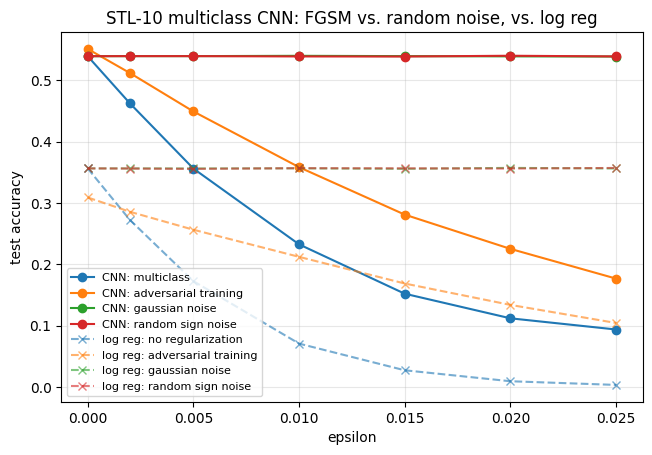

In [40]:
overlay_plot("STL-10 multiclass CNN: FGSM vs. random noise, vs. log reg", EPSILONS_STL, stl_cnn_results_mc, "stl_multiclass")

# Part 3 - STL-10 ResNet-18

For the ResNet experiments, a pretrained ResNet-18 from torchvision is used. The pretrained weights are kept frozen and only the final classification layer is replaced and trained for STL-10.

## 3.1 Binary model training

In [41]:
print("Training ResNet with frozen backbone:")

stl_resnet_bin = train_binary_resnet(stl_train_loader_bin_img, epochs=20)

test_acc = eval_binary(stl_resnet_bin, stl_test_loader_bin_img)

print("Test accuracy:", round(test_acc, 4))

Training ResNet with frozen backbone:
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


epoch 1 | loss: 0.7525 | train acc: 0.498
epoch 5 | loss: 0.4449 | train acc: 0.819
epoch 10 | loss: 0.3445 | train acc: 0.863
epoch 15 | loss: 0.3023 | train acc: 0.876
epoch 20 | loss: 0.285 | train acc: 0.883
Test accuracy: 0.8294


## 3.2 FGSM on the binary model

In [42]:
resnet_bin_accs = []

for epsilon in EPSILONS_STL:
    if epsilon == 0.0:
        acc = test_acc
    else:
        acc = evaluate_fgsm_binary(stl_resnet_bin, stl_test_loader_bin_img, epsilon)

    resnet_bin_accs.append(acc)

stl_resnet_results_bin = {"binary": resnet_bin_accs}

print("Binary accuracies:")
print([round(acc, 3) for acc in resnet_bin_accs])

Binary accuracies:
[0.829, 0.434, 0.207, 0.142, 0.133, 0.151, 0.168]


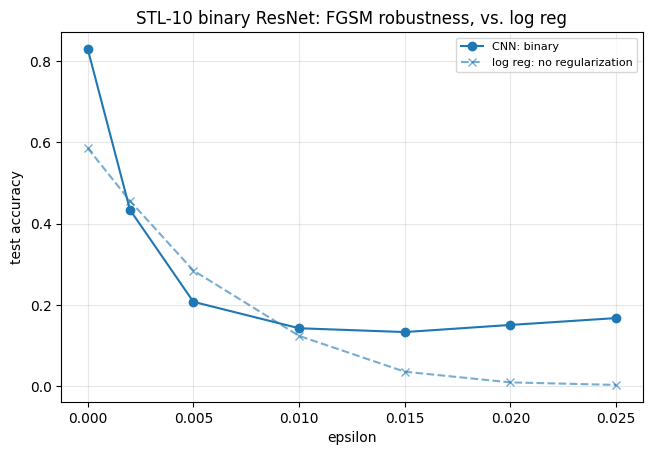

In [43]:
overlay_plot("STL-10 binary ResNet: FGSM robustness, vs. log reg", EPSILONS_STL, stl_resnet_results_bin, "stl_binary")

## 3.3 Visualizing adversarial examples

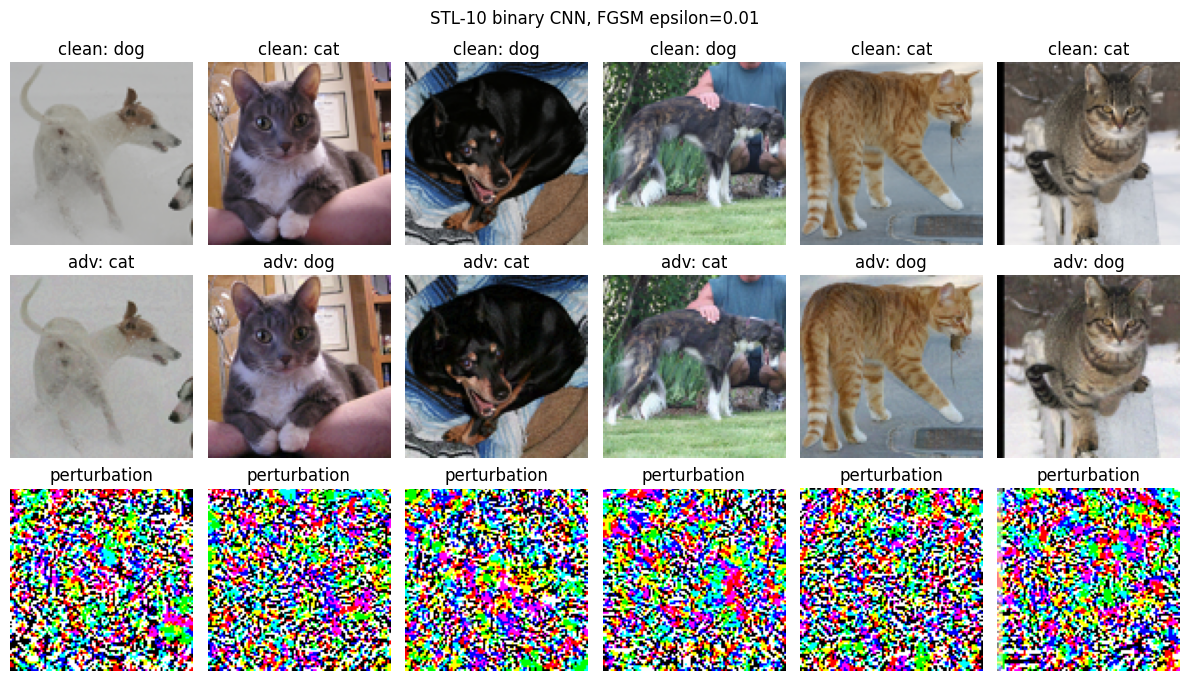

In [44]:
show_stl_binary_adversarials(stl_resnet_bin, stl_test_loader_bin_img, epsilon=0.01)

## 3.4 Adversarial training

In [45]:
print("Training FGSM adversarial ResNet (STL-10):")

stl_resnet_bin_adv = train_binary_resnet_adversarial(stl_train_loader_bin_img, epsilon=0.015, epochs=20)

clean_acc_adv = eval_binary(stl_resnet_bin_adv, stl_test_loader_bin_img)

print("Clean test accuracy (adversarial training):", round(clean_acc_adv, 4))

Training FGSM adversarial ResNet (STL-10):
epoch 1 | loss: 1.0753 | train acc (clean): 0.491
epoch 5 | loss: 0.7681 | train acc (clean): 0.826
epoch 10 | loss: 0.7111 | train acc (clean): 0.847
epoch 15 | loss: 0.6947 | train acc (clean): 0.868
epoch 20 | loss: 0.6871 | train acc (clean): 0.867
Clean test accuracy (adversarial training): 0.8594


In [46]:
resnet_bin_adv_accs = []

for epsilon in EPSILONS_STL:
    if epsilon == 0.0:
        acc = clean_acc_adv
    else:
        acc = evaluate_fgsm_binary(stl_resnet_bin_adv, stl_test_loader_bin_img, epsilon)

    resnet_bin_adv_accs.append(acc)

stl_resnet_results_bin["adversarial training"] = resnet_bin_adv_accs

print("Adversarial training accuracies:")
print([round(acc, 3) for acc in resnet_bin_adv_accs])

Adversarial training accuracies:
[0.859, 0.485, 0.296, 0.229, 0.216, 0.227, 0.242]


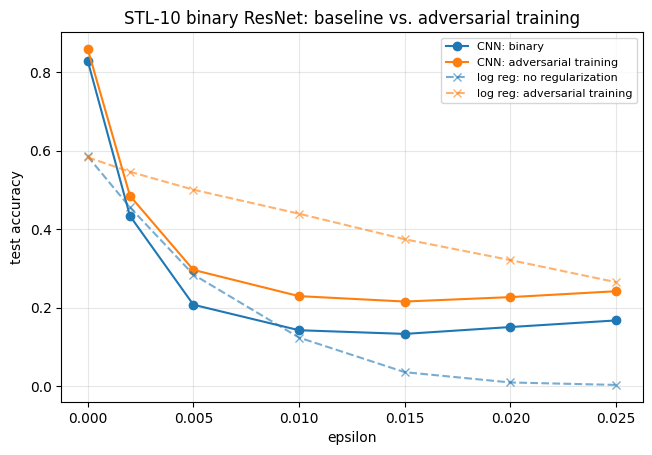

In [47]:
overlay_plot("STL-10 binary ResNet: baseline vs. adversarial training", EPSILONS_STL, stl_resnet_results_bin, "stl_binary")

## 3.5 Comparison with random noise

In [48]:
for noise_name, noise_fn in [("gaussian noise", gaussian_noise_attack), ("random sign noise", random_sign_attack)]:
    noise_accs = []

    for epsilon in EPSILONS_STL:
        if epsilon == 0.0:
            acc = test_acc
        else:
            acc = evaluate_noise_binary(stl_resnet_bin, stl_test_loader_bin_img, epsilon, noise_fn)

        noise_accs.append(acc)

    stl_resnet_results_bin[noise_name] = noise_accs

    print(noise_name + " accuracies:")
    print([round(acc, 3) for acc in noise_accs])

gaussian noise accuracies:
[0.829, 0.829, 0.828, 0.83, 0.828, 0.831, 0.824]
random sign noise accuracies:
[0.829, 0.827, 0.829, 0.824, 0.822, 0.819, 0.811]


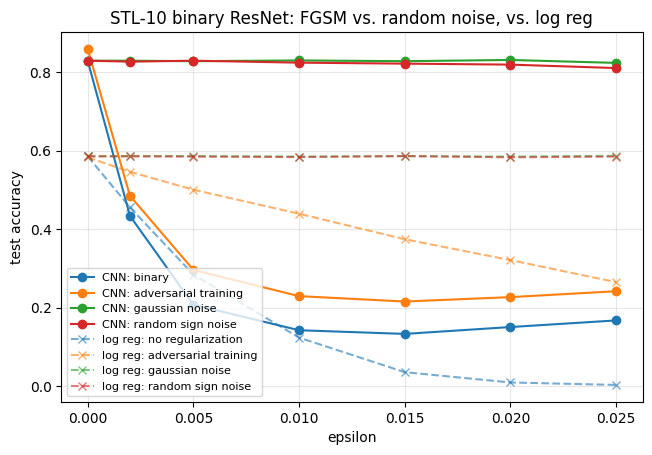

In [49]:
overlay_plot("STL-10 binary ResNet: FGSM vs. random noise, vs. log reg", EPSILONS_STL, stl_resnet_results_bin, "stl_binary")

## 3.6 Multiclass model training

In [50]:
print("Training multiclass ResNet:")

stl_resnet_mc = train_multiclass_resnet(stl_train_loader, epochs=20)

test_acc = eval_multiclass(stl_resnet_mc, stl_test_loader)

print("Clean test accuracy:", round(test_acc, 4))

Training multiclass ResNet:
epoch 1 | loss: 1.5238 | train acc: 0.5072
epoch 5 | loss: 0.5869 | train acc: 0.813
epoch 10 | loss: 0.4845 | train acc: 0.8384
epoch 15 | loss: 0.4219 | train acc: 0.8556
epoch 20 | loss: 0.3901 | train acc: 0.8692
Clean test accuracy: 0.7907


## 3.7 FGSM on the multiclass models

In [51]:
stl_mc_accs = []

for epsilon in EPSILONS_STL:
    if epsilon == 0.0:
        acc = test_acc
    else:
        acc = evaluate_fgsm_multiclass(stl_resnet_mc, stl_test_loader, epsilon)

    stl_mc_accs.append(acc)

stl_resnet_results_mc = {"multiclass": stl_mc_accs}

print("Multiclass accuracies:")
print([round(acc, 3) for acc in stl_mc_accs])

Multiclass accuracies:
[0.791, 0.347, 0.153, 0.085, 0.074, 0.073, 0.074]


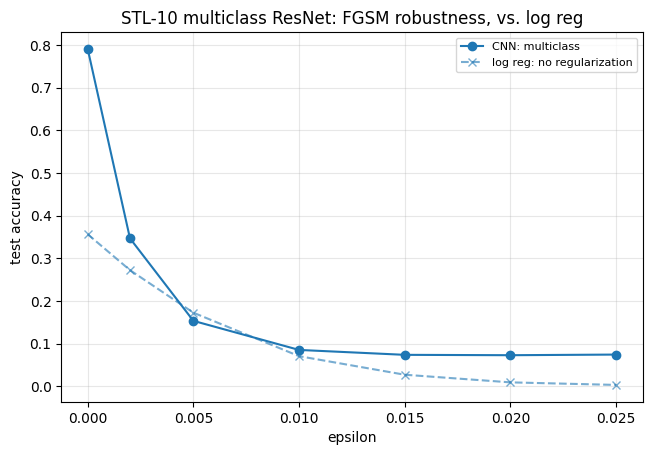

In [52]:
overlay_plot("STL-10 multiclass ResNet: FGSM robustness, vs. log reg", EPSILONS_STL, stl_resnet_results_mc, "stl_multiclass")

## 3.8 Visualizing adversarial examples

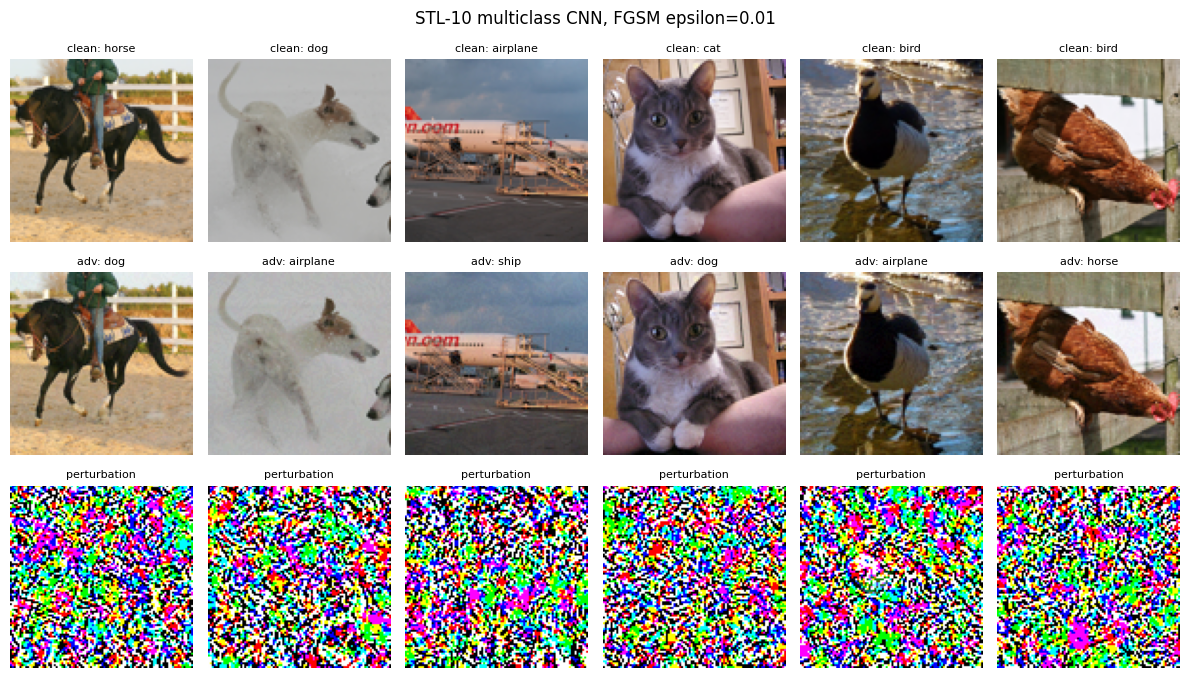

In [53]:
show_stl_multiclass_adversarials(stl_resnet_mc, stl_test_loader, epsilon=0.01)

## 3.9 Adversarial training

In [54]:
print("Training FGSM adversarial ResNet (STL-10):")

stl_resnet_mc_adv = train_multiclass_resnet_adversarial(stl_train_loader, epsilon=0.015, adv_weight=0.5, epochs=20)

clean_acc_adv = eval_multiclass(stl_resnet_mc_adv, stl_test_loader)

print("Clean test accuracy (adversarial training):", round(clean_acc_adv, 4))

Training FGSM adversarial ResNet (STL-10):
epoch 1 | loss: 2.3308 | train acc (clean): 0.4968
epoch 5 | loss: 1.6192 | train acc (clean): 0.7878
epoch 10 | loss: 1.5559 | train acc (clean): 0.799
epoch 15 | loss: 1.5431 | train acc (clean): 0.7976
epoch 20 | loss: 1.5243 | train acc (clean): 0.7988
Clean test accuracy (adversarial training): 0.7881


In [55]:
stl_mc_adv_accs = []

for epsilon in EPSILONS_STL:
    if epsilon == 0.0:
        acc = clean_acc_adv
    else:
        acc = evaluate_fgsm_multiclass(stl_resnet_mc_adv, stl_test_loader, epsilon)

    stl_mc_adv_accs.append(acc)

stl_resnet_results_mc["adversarial training"] = stl_mc_adv_accs

print("Adversarial training accuracies:")
print([round(acc, 3) for acc in stl_mc_adv_accs])

Adversarial training accuracies:
[0.788, 0.446, 0.257, 0.186, 0.165, 0.16, 0.161]


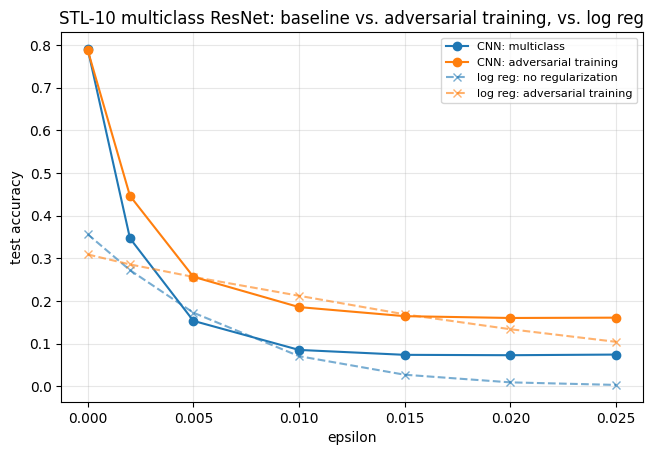

In [56]:
overlay_plot("STL-10 multiclass ResNet: baseline vs. adversarial training, vs. log reg", EPSILONS_STL, stl_resnet_results_mc, "stl_multiclass")

## 3.10 Comparison with random noise

In [57]:
for noise_name, noise_fn in [("gaussian noise", gaussian_noise_attack), ("random sign noise", random_sign_attack)]:
    noise_accs = []

    for epsilon in EPSILONS_STL:
        if epsilon == 0.0:
            acc = test_acc
        else:
            acc = evaluate_noise_multiclass(stl_resnet_mc, stl_test_loader, epsilon, noise_fn)

        noise_accs.append(acc)

    stl_resnet_results_mc[noise_name] = noise_accs

    print(noise_name + " accuracies:")
    print([round(acc, 3) for acc in noise_accs])

gaussian noise accuracies:
[0.791, 0.79, 0.79, 0.789, 0.789, 0.789, 0.788]
random sign noise accuracies:
[0.791, 0.789, 0.789, 0.786, 0.783, 0.776, 0.77]


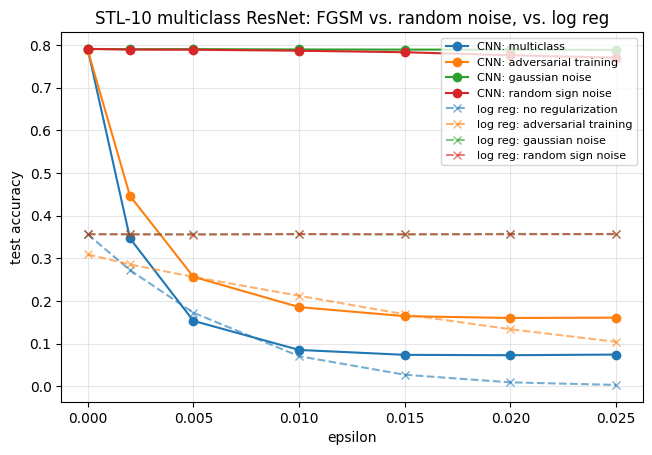

In [58]:
overlay_plot("STL-10 multiclass ResNet: FGSM vs. random noise, vs. log reg", EPSILONS_STL, stl_resnet_results_mc, "stl_multiclass")

# Part 4 - Summary
We already show adversarial accuracies. This is just
the clean (eps=0) accuracy for all three architectures side by side.

In [59]:
summary_rows = [
    (
        "MNIST binary",
        cnn_results_bin["binary"][0],
        None,
        "mnist_binary"
    ),
    (
        "MNIST multiclass",
        cnn_results_mc["multiclass"][0],
        None,
        "mnist_multiclass"
    ),
    (
        "STL-10 binary",
        stl_cnn_results_bin["binary"][0],
        stl_resnet_results_bin["binary"][0],
        "stl_binary"
    ),
    (
        "STL-10 multiclass",
        stl_cnn_results_mc["multiclass"][0],
        stl_resnet_results_mc["multiclass"][0],
        "stl_multiclass"
    )
]

for setting, cnn_acc, resnet_acc, logreg_key in summary_rows:
    logreg_acc = logreg_results[logreg_key]["no regularization"][0]

    print(setting)
    print("CNN clean accuracy:", round(cnn_acc, 4))



    if resnet_acc is not None:
      print("ResNet clean accuracy:", round(resnet_acc, 4))
    else:
      print("ResNet clean accuracy: n/a")


    print("Logistic regression clean accuracy:", round(logreg_acc, 4))
    print()

MNIST binary
CNN clean accuracy: 0.9975
ResNet clean accuracy: n/a
Logistic regression clean accuracy: 0.9677

MNIST multiclass
CNN clean accuracy: 0.9909
ResNet clean accuracy: n/a
Logistic regression clean accuracy: 0.9262

STL-10 binary
CNN clean accuracy: 0.6613
ResNet clean accuracy: 0.8294
Logistic regression clean accuracy: 0.5856

STL-10 multiclass
CNN clean accuracy: 0.5395
ResNet clean accuracy: 0.7907
Logistic regression clean accuracy: 0.3565



## 5.1 Save the results and the models

In [60]:
# AI assistance: ChatGPT was used to check that this saving cell is consistent and includes all trained models.

os.makedirs("saved_models", exist_ok=True)
models_to_save = {
    "cnn_bin_MNIST": cnn_bin_MNIST,
    "cnn_bin_MNIST_adv": cnn_bin_MNIST_adv,
    "cnn_mc_MNIST": cnn_mc_MNIST,
    "cnn_mc_adv": cnn_mc_adv,

    "stl_cnn_bin": stl_cnn_bin,
    "stl_cnn_bin_adv": stl_cnn_bin_adv,
    "stl_cnn_mc": stl_cnn_mc,
    "stl_cnn_mc_adv": stl_cnn_mc_adv,

    "stl_resnet_bin": stl_resnet_bin,
    "stl_resnet_bin_adv": stl_resnet_bin_adv,
    "stl_resnet_mc": stl_resnet_mc,
    "stl_resnet_mc_adv": stl_resnet_mc_adv
}

for name, model in models_to_save.items():
    file_path = "saved_models/" + name + ".pt"
    torch.save(model.state_dict(), file_path)

print("Saved", len(models_to_save), "models to saved_models/")

Saved 12 models to saved_models/


In [61]:
cnn_results = {
    "mnist_binary": {
        "epsilons": EPSILONS_MNIST,
        **cnn_results_bin
    },
    "mnist_multiclass": {
        "epsilons": EPSILONS_MNIST,
        **cnn_results_mc
    },
    "stl_cnn_binary": {
        "epsilons": EPSILONS_STL,
        **stl_cnn_results_bin
    },
    "stl_cnn_multiclass": {
        "epsilons": EPSILONS_STL,
        **stl_cnn_results_mc
    },
    "stl_resnet_binary": {
        "epsilons": EPSILONS_STL,
        **stl_resnet_results_bin
    },
    "stl_resnet_multiclass": {
        "epsilons": EPSILONS_STL,
        **stl_resnet_results_mc
    }
}

with open("nn_results.json", "w") as f:
    json.dump(cnn_results, f, indent=2)

print("Saved nn_results.json")

Saved nn_results.json
